# Species comparison
## GO plots
### Author: Martin Loza
### Date: 26/01/15

Let's plot the results from DAVID GO

In [34]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init 
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
})

# Local variables 
seed = 777
date = "260115"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/06_Species_comparison_lncRNA_TF/Results"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/06_Species_comparison_lncRNA_TF/Plots/"
# Local Functions



### Load and setup the data

In [35]:
# Load the results from the GO analysis
# We have different test, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)
# Select files that start with "DAVID_"
files <- files[str_starts(files, "DAVID_")]

# Load the data for each species
for (file in files) {
    # Remove the DAVID prefix
    test_name <- str_replace(file, "DAVID_GO_", "")
    # Get the first word and remove the rest
    test_name <- str_split(test_name, "_")[[1]][1]
    
    data_list[[test_name]] <- read.csv2(file.path(in_dir, file), sep = ",", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL) %>%
        mutate(across(where(is.character), ~str_remove_all(., '"')))
    # Remove the X. prefix from column names if present
    colnames(data_list[[test_name]]) <- str_replace_all(colnames(data_list[[test_name]]), "^X\\.", "")
    # Remove the last "." from column names if present
    colnames(data_list[[test_name]]) <- str_replace_all(colnames(data_list[[test_name]]), "\\.$", "")
    

    # Transform selected columns to numeric
    selected_cols <- c("Count", "Benjamini", "FDR")
    data_list[[test_name]][selected_cols] <- lapply(data_list[[test_name]][selected_cols], as.numeric)
}

head(data_list[["Conserved"]], 10)

,Category,Term,Genes,Count,List.Total,Pop.Hits,Pop.Total,P.Value,Benjamini,Fold.Enrichment,Bonferroni,FDR,Fisher.Exact
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,GOTERM_BP_DIRECT,lens development in camera-type eye,50.00%,2,4,7,1075,1.94e-2,0.719,76.79,5.16e-1,0.719,2.17e-4


### Prepare the data for plotting

In [36]:
# Prepare data for plotting - select top terms by FDR

plot_data_list <- list()

for (test in names(data_list)) {
    # Select top N terms with lowest FDR
    plot_data_list[[test]] <- data_list[[test]] %>%
        arrange(FDR) %>%
        mutate(
            # Create a clean term name (remove GO ID if present)
            Term_clean = str_replace(Term, "~.*", ""),
            Term_clean = str_trunc(Term_clean, width = 60, side = "right"),
            # Calculate -log10(FDR) for better visualization
            neg_log_FDR = -log10(FDR)
        )
}

### GO Enrichment Plot

Lollipop plot showing GO enrichment results with -log10(FDR) and gene count.

In [37]:
# Create separate plots for each test, then combine with patchwork
options(repr.plot.width=12, repr.plot.height=8)

# Prepare data with proper ordering for each test
human_data <- plot_data_list[["Human"]] %>%
    arrange(neg_log_FDR) %>%
    mutate(Term_clean = factor(Term_clean, levels = unique(Term_clean)))

conserved_data <- plot_data_list[["Conserved"]] %>%
    arrange(neg_log_FDR) %>%
    mutate(Term_clean = factor(Term_clean, levels = unique(Term_clean)))

# Get the range of Count values across both tests for shared scale
count_range <- range(c(human_data$Count, conserved_data$Count))

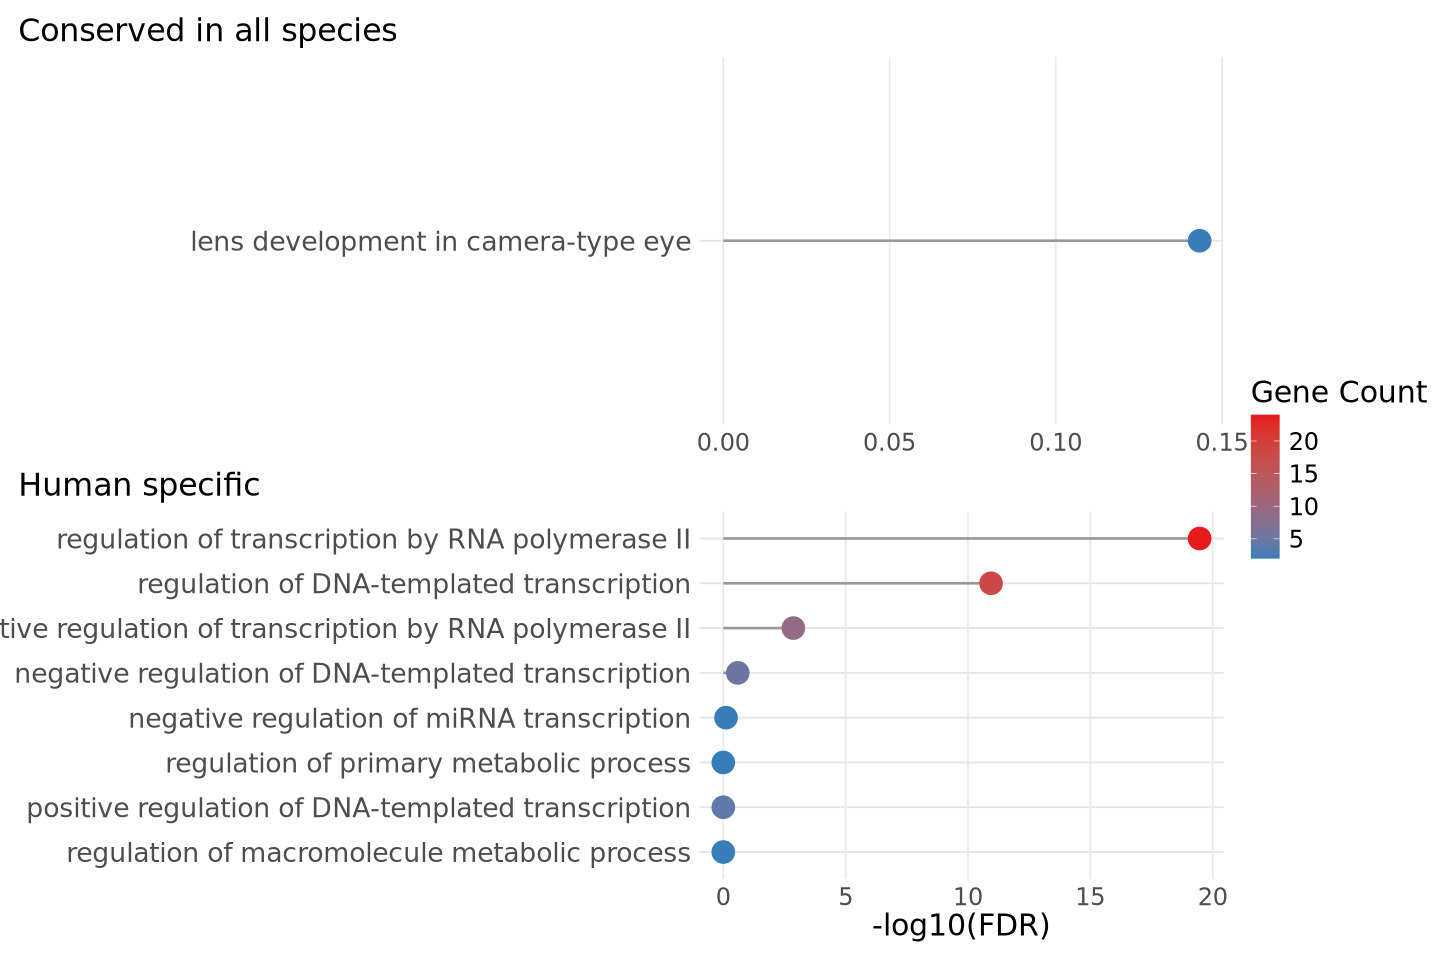

In [48]:
# Create conserved plot with color by count and shared scale
p_conserved_count <- conserved_data %>%
    ggplot(aes(x = neg_log_FDR, y = Term_clean)) +
    geom_segment(aes(x = 0, xend = neg_log_FDR, y = Term_clean, yend = Term_clean),
                 color = "gray60", linewidth = line_size * 0.5) +
    geom_point(aes(color = Count), size = dot_size * 1.5) +
    scale_color_gradient(low = blue, high = red, name = "Gene Count", limits = count_range) +
    theme_minimal() +
    labs(x = NULL, y = NULL, title = "Conserved in all species") +
    theme(
        text = element_text(size = text_size),
        axis.text.y = element_text(size = text_size - 2),
        plot.title = element_text(size = text_size + 1, hjust = 0),
        plot.title.position = "plot",
        legend.position = "right",
        panel.grid.major.y = element_line(color = "gray90"),
        panel.grid.minor = element_blank()
    )

# Create human plot with color by count and shared scale
p_human_count <- human_data %>%
    ggplot(aes(x = neg_log_FDR, y = Term_clean)) +
    geom_segment(aes(x = 0, xend = neg_log_FDR, y = Term_clean, yend = Term_clean),
                 color = "gray60", linewidth = line_size * 0.5) +
    geom_point(aes(color = Count), size = dot_size * 1.5) +
    scale_color_gradient(low = blue, high = red, name = "Gene Count", limits = count_range) +
    theme_minimal() +
    labs(x = "-log10(FDR)", y = NULL, title = "Human specific") +
    theme(
        text = element_text(size = text_size),
        axis.text.y = element_text(size = text_size - 2),
        plot.title = element_text(size = text_size + 1, hjust = 0),
        plot.title.position = "plot",
        legend.position = "right",
        panel.grid.major.y = element_line(color = "gray90"),
        panel.grid.minor = element_blank()
    )

# Combine plots with patchwork
options(repr.plot.width=12, repr.plot.height=8)
p_lollipop <- p_conserved_count / p_human_count + 
    plot_layout(guides = "collect") +
    plot_annotation(theme = theme(plot.title = element_text(size = text_size + 2)))

p_lollipop


### Save plot

In [15]:
# Save the GO enrichment plot
ggsave(filename = file.path(out_dir, paste0("Fig_3_GO_enrichment_", date, ".pdf")),
    plot = p_lollipop, 
    width = width * 0.6, height = 8.0, units = "in", dpi = dpi)